In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import silhouette_score,calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from kneed import KneeLocator

import warnings
warnings.filterwarnings('ignore')

In [15]:
seed = 42

In [16]:
df = pd.read_csv('Dataset.csv')
X = df.drop(['46'], axis=1)
y = df['46']

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [17]:
pca = PCA(n_components=46)
X1 = pca.fit_transform(X)

In [35]:
def visualize_pca_tsne(X, model, title, random_state=seed, clustering=True):

    cluster_labels = model.fit_predict(X)

    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X)

    pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'Cluster': cluster_labels.astype(str)})

    tsne = TSNE(n_components=2, random_state=seed)
    X_tsne = tsne.fit_transform(X)

    tsne_df = pd.DataFrame({'TSNE1': X_tsne[:, 0], 'TSNE2': X_tsne[:, 1], 'Cluster': cluster_labels.astype(str)})

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plt.suptitle(title, fontsize=16)

    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60, alpha=0.8, ax=axes[0])
    axes[0].set_title(f'PCA Visualization')

    sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='Set2', s=60, alpha=0.8, ax=axes[1])
    axes[1].set_title(f't-SNE Visualization')

    plt.tight_layout()
    plt.show()

    return {'cluster_labels': cluster_labels, 'pca_df': pca_df, 'tsne_df': tsne_df}

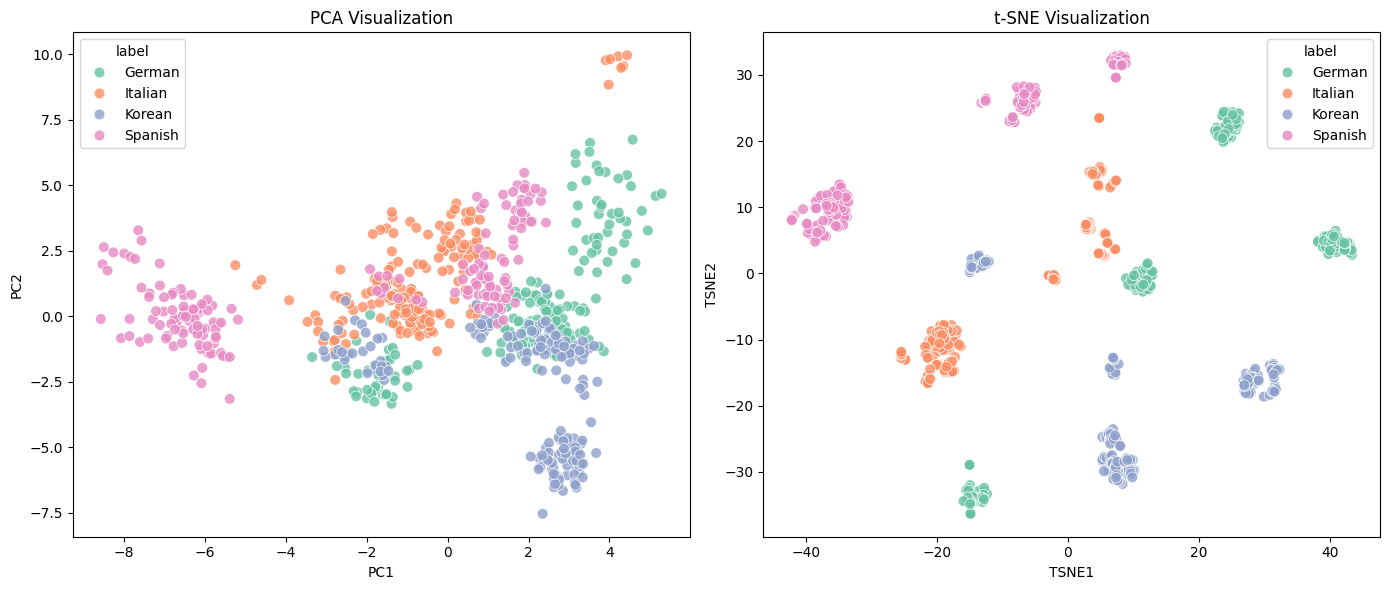

In [36]:
pca = PCA(n_components=2, random_state=seed)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'label': y.values})

tsne = TSNE(n_components=2,random_state=seed)

X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame({'TSNE1': X_tsne[:, 0], 'TSNE2': X_tsne[:, 1],'label': y.values})


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', palette='Set2', ax=axes[0], s=60, alpha=0.8)
axes[0].set_title('PCA Visualization')

sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='label', palette='Set2', ax=axes[1], s=60, alpha=0.8)
axes[1].set_title('t-SNE Visualization')

plt.tight_layout()
plt.show()

# K-Means

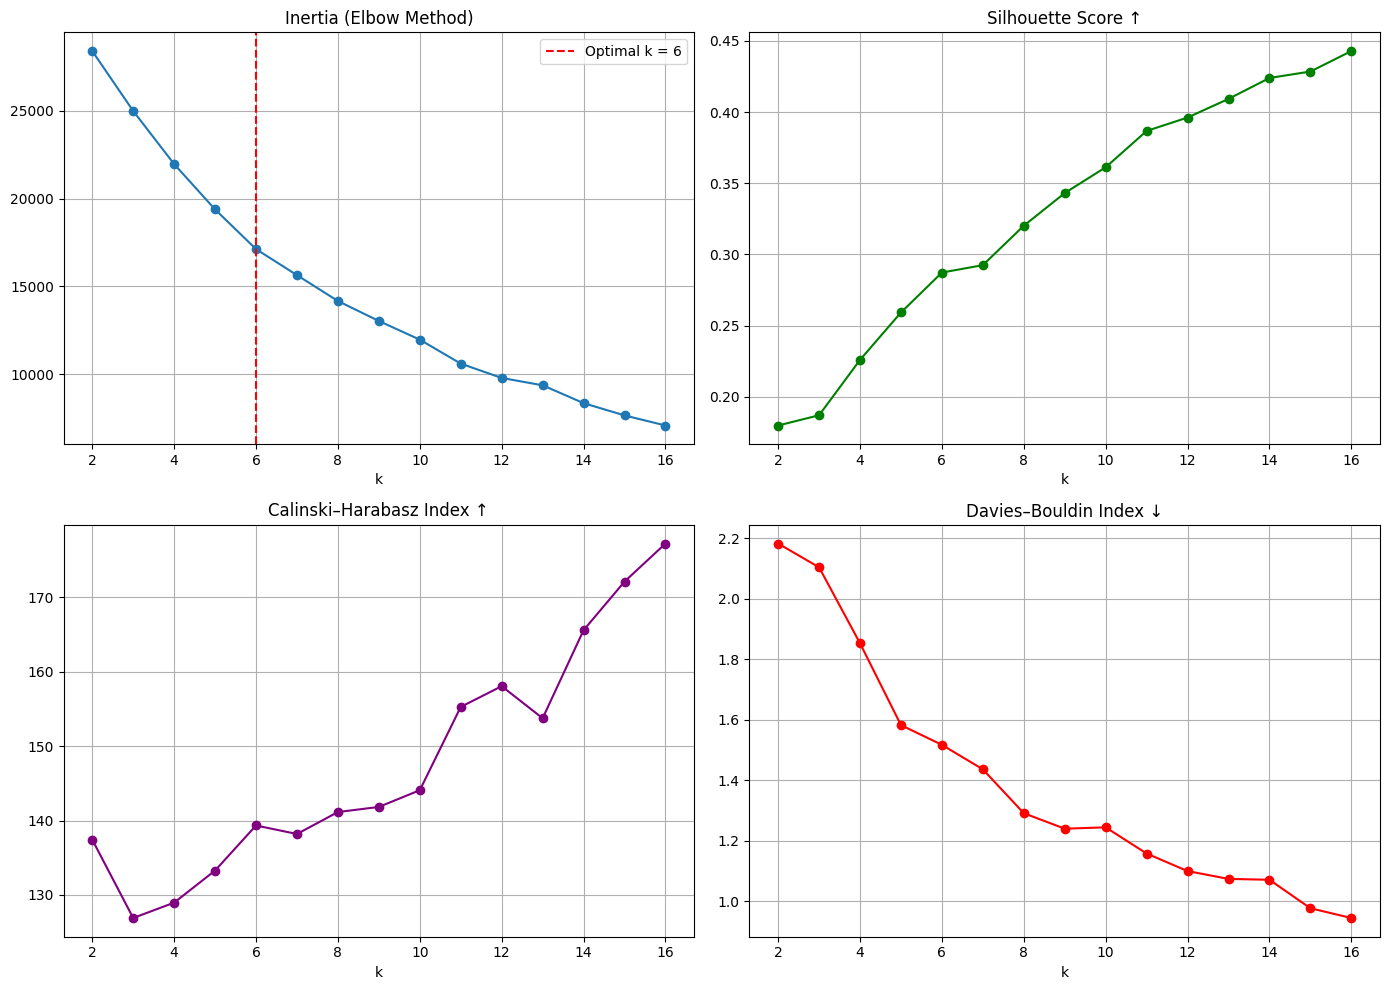

Optimal k (Elbow): 6


In [37]:
def kmeans_eval(X, k_min=2, k_max=16,random_state=seed):

    k_min = int(k_min)
    k_max = int(k_max)

    ks = range(k_min, k_max + 1)

    inertias = []
    silhouettes = []
    ch_scores = []
    db_scores = []

    for k in ks:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(X)

        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, labels))
        ch_scores.append(calinski_harabasz_score(X, labels))
        db_scores.append(davies_bouldin_score(X, labels))

    knee = KneeLocator(ks, inertias, curve='convex', direction='decreasing')

    optimal_k = knee.knee

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(ks, inertias, marker='o')
    if optimal_k:
        axes[0, 0].axvline(optimal_k, linestyle='--', color='red',
                           label=f'Optimal k = {optimal_k}')
        axes[0, 0].legend()
    axes[0, 0].set_title('Inertia (Elbow Method)')
    axes[0, 0].set_xlabel('k')
    axes[0, 0].grid(True)

    axes[0, 1].plot(ks, silhouettes, marker='o', color='green')
    axes[0, 1].set_title('Silhouette Score ↑')
    axes[0, 1].set_xlabel('k')
    axes[0, 1].grid(True)

    axes[1, 0].plot(ks, ch_scores, marker='o', color='purple')
    axes[1, 0].set_title('Calinski–Harabasz Index ↑')
    axes[1, 0].set_xlabel('k')
    axes[1, 0].grid(True)

    axes[1, 1].plot(ks, db_scores, marker='o', color='red')
    axes[1, 1].set_title('Davies–Bouldin Index ↓')
    axes[1, 1].set_xlabel('k')
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

    return {'k': list(ks), 'inertia': inertias, 'silhouette': silhouettes, 'CH': ch_scores, 'DB': db_scores, 'optimal_k_elbow': optimal_k}

results = kmeans_eval(X)
print('Optimal k (Elbow):', results['optimal_k_elbow'])

In [40]:
def kmeans_ari_nmi(X, y_true, k_min=2, k_max=16, random_state=seed):

    ari_scores = []
    nmi_scores = []

    k_range = range(int(k_min), int(k_max) + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(X)

        ari_scores.append(adjusted_rand_score(y_true, labels))
        nmi_scores.append(normalized_mutual_info_score(y_true, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(k_range, ari_scores, marker='o', color='blue')
    axes[0].set_title('Adjusted Rand Index (ARI)')
    axes[0].set_xlabel('Number of clusters (k)')
    axes[0].set_ylabel('ARI')
    axes[0].grid(True)

    axes[1].plot(k_range, nmi_scores, marker='o', color='green')
    axes[1].set_title('Normalized Mutual Information (NMI)')
    axes[1].set_xlabel('Number of clusters (k)')
    axes[1].set_ylabel('NMI')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return {'k': list(k_range), 'ARI': ari_scores, 'NMI': nmi_scores}

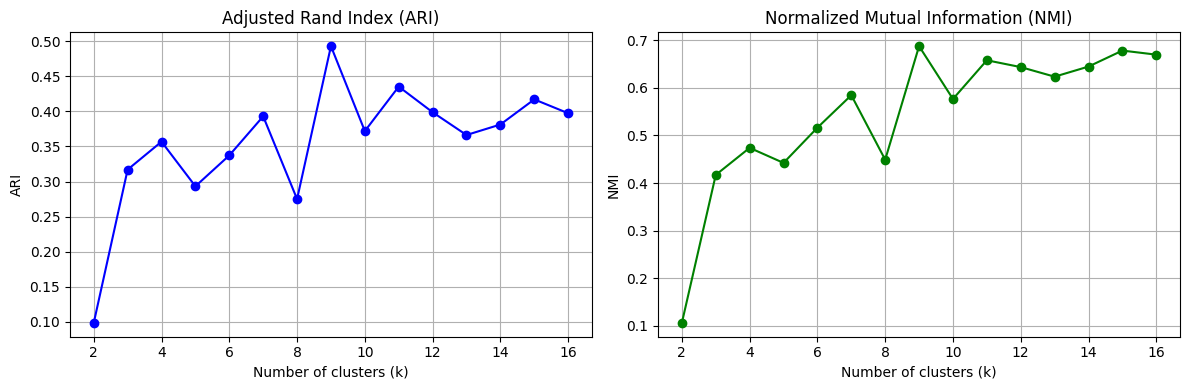

In [41]:
results2 = kmeans_ari_nmi(X, y)

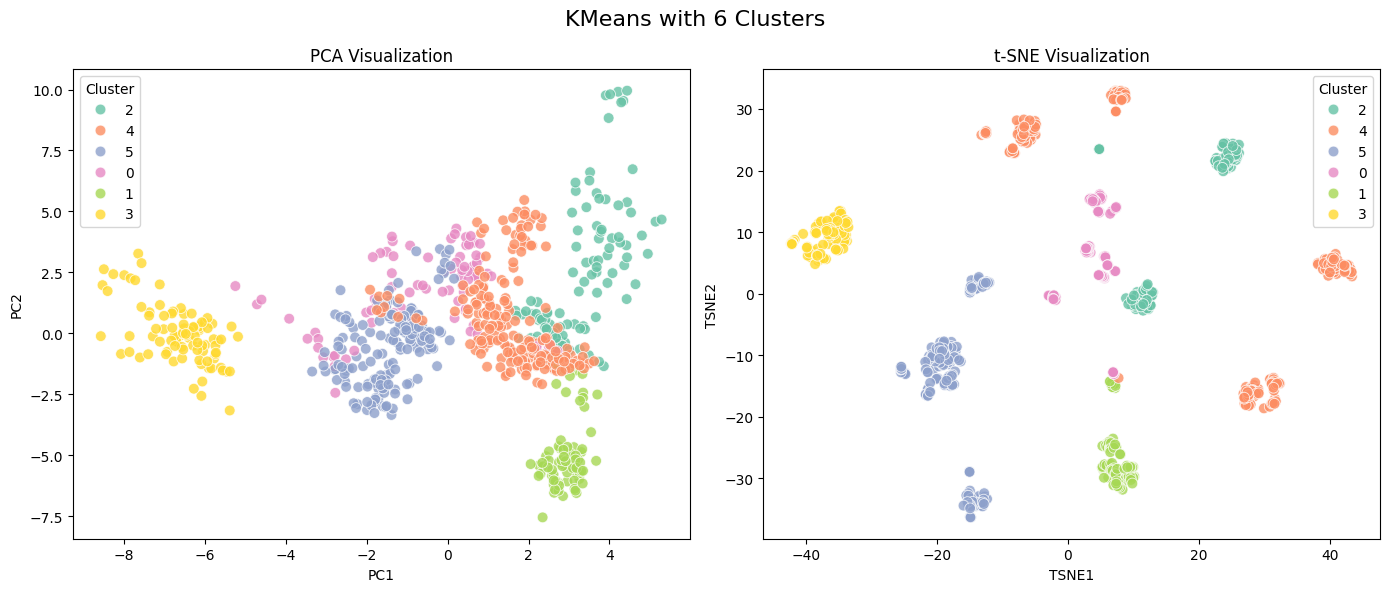

In [42]:
kmeans = KMeans(n_clusters=6, random_state=seed, n_init=10)
kmeans_res = visualize_pca_tsne(X, kmeans, 'KMeans with 6 Clusters')

# Hierarchical

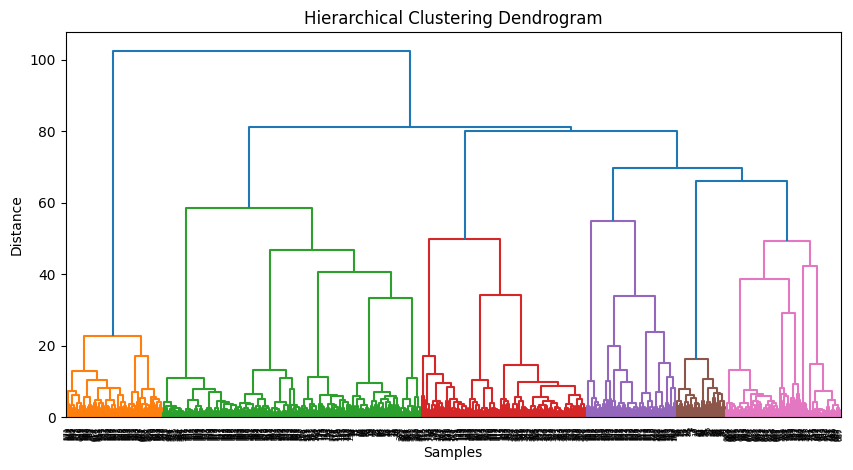

In [43]:
Z = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, color_threshold=65)
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

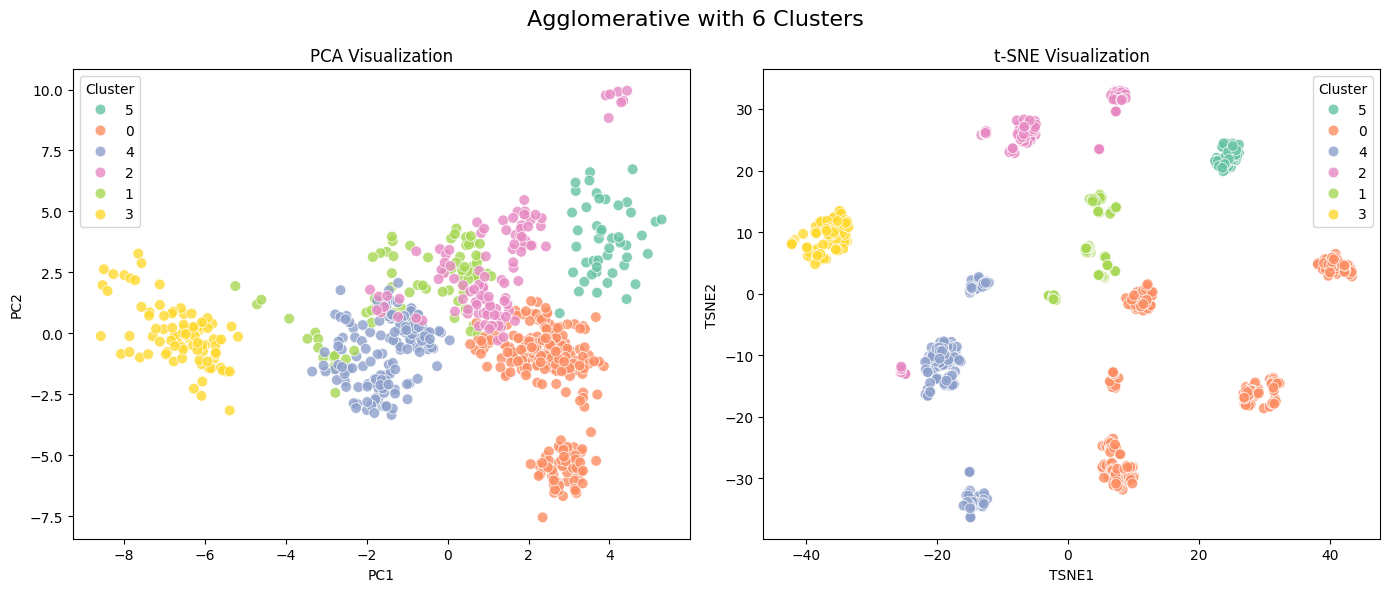

Silhouette Score (Agglomerative, k=6): 0.27823432746901744


In [44]:
agglomerative = AgglomerativeClustering(n_clusters=6,linkage='ward')
agglomerative_res = visualize_pca_tsne(X, agglomerative, 'Agglomerative with 6 Clusters')

labels_agglo = agglomerative.fit_predict(X)
silhouette_agglo = silhouette_score(X, labels_agglo)

print('Silhouette Score (Agglomerative, k=6):', silhouette_agglo)

In [ ]:
def hierarchical_metrics_by_k(X, methods=('ward',), k_min=2, k_max=16, plot=True):

    all_results = {}

    for method in methods:
        Z = linkage(X, method=method)

        rows = []
        for k in range(k_min, k_max + 1):
            labels = fcluster(Z, t=k, criterion='maxclust')

            sil = silhouette_score(X, labels)
            db  = davies_bouldin_score(X, labels)
            ch  = calinski_harabasz_score(X, labels)

            rows.append({'k': k, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch})

        df_metrics = pd.DataFrame(rows)
        all_results[method] = df_metrics

        print(f'Linkage method: {method}')
        print(df_metrics.to_string(index=False))

        best_sil_k = df_metrics.loc[df_metrics['silhouette'].idxmax(), 'k']
        best_db_k  = df_metrics.loc[df_metrics['davies_bouldin'].idxmin(), 'k']
        best_ch_k  = df_metrics.loc[df_metrics['calinski_harabasz'].idxmax(), 'k']

        print(f'\nBest k by Silhouette (max): {best_sil_k}')
        print(f'Best k by Davies-Bouldin (min): {best_db_k}')
        print(f'Best k by Calinski-Harabasz (max): {best_ch_k}')

        if plot:
            ks = df_metrics['k'].values

            plt.figure(figsize=(14,4))

            plt.subplot(1,3,1)
            plt.plot(ks, df_metrics['silhouette'], marker='o')
            plt.title(f'Silhouette vs k ({method})')
            plt.xlabel('k')
            plt.ylabel('Silhouette')
            plt.grid(True)

            plt.subplot(1,3,2)
            plt.plot(ks, df_metrics['calinski_harabasz'], marker='o')
            plt.title(f'CH vs k ({method})')
            plt.xlabel('k')
            plt.ylabel('CH (higher is better)')
            plt.grid(True)

            plt.subplot(1,3,3)
            plt.plot(ks, df_metrics['davies_bouldin'], marker='o')
            plt.title(f'DB vs k ({method})')
            plt.xlabel('k')
            plt.ylabel('DB (lower is better)')
            plt.grid(True)

            plt.tight_layout()
            plt.show()

    return all_results

Linkage method: ward
 k  silhouette  davies_bouldin  calinski_harabasz
 2    0.225346        1.190633         132.093041
 3    0.172946        2.045926         121.045967
 4    0.210664        1.910890         126.926026
 5    0.246693        1.710853         128.964811
 6    0.278234        1.470529         133.851658
 7    0.287891        1.470372         136.448581
 8    0.309898        1.342063         139.845721
 9    0.332572        1.288754         142.308320
10    0.359516        1.207852         147.461561
11    0.383720        1.193123         153.240637
12    0.397566        1.109215         157.753172
13    0.409969        1.072185         163.157920
14    0.427225        1.055053         168.934155
15    0.432940        1.032543         172.541149
16    0.446847        1.023559         177.771822

Best k by Silhouette (max): 16
Best k by Davies-Bouldin (min): 16
Best k by Calinski-Harabasz (max): 16


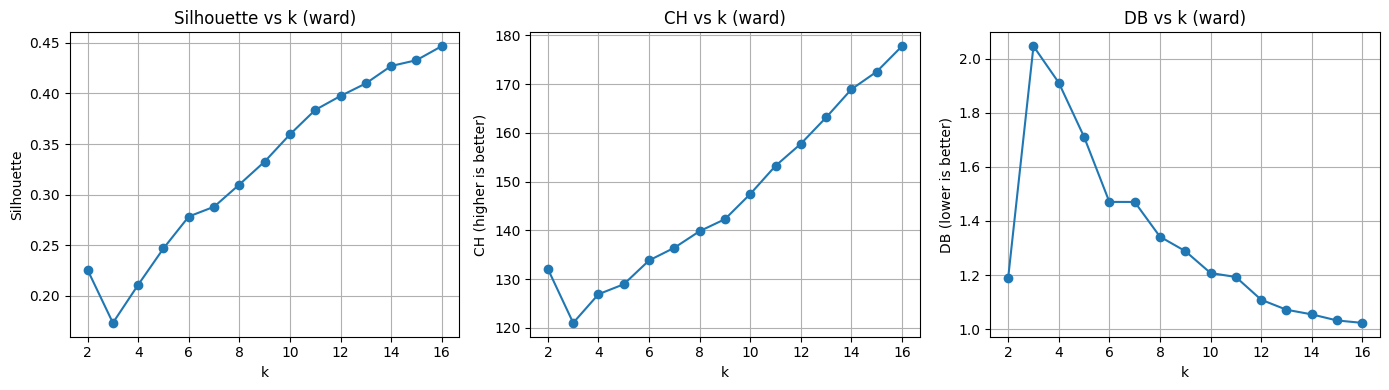

In [46]:
results_hier = hierarchical_metrics_by_k(X, methods=('ward',), k_min=2, k_max=16, plot=True)

# DBSCAN

In [ ]:
X_use = X

min_samples_list = [10, 15, 20, 25, 30]
results = []

for ms in min_samples_list:
    nn = NearestNeighbors(n_neighbors=ms).fit(X_use)
    distances, _ = nn.kneighbors(X_use)
    k_dist = np.sort(distances[:, -1])

    x = np.arange(len(k_dist))
    knee = KneeLocator(x, k_dist, curve='convex', direction='increasing')
    eps0 = k_dist[knee.knee] if knee.knee else np.percentile(k_dist, 90)

    for mult in [0.8, 0.9, 1.0, 1.1, 1.2]:
        eps = eps0 * mult
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_use)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_frac = np.mean(labels == -1)

        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_use[mask], labels[mask])
            db = davies_bouldin_score(X_use[mask], labels[mask])
        else:
            sil, db = None, None

        results.append((ms, eps, n_clusters, noise_frac, sil, db))

results_sorted = sorted([r for r in results if r[4] is not None],
                        key=lambda x: x[4], reverse=True)

print('Top 10 configs:')
for r in results_sorted[:10]:
    print(f'min_samples={r[0]}, eps={r[1]:.3f}, clusters={r[2]}, noise={r[3]:.2%}, sil={r[4]:.3f}, DB={r[5]:.3f}')


Top 10 configs:
min_samples=15, eps=4.825, clusters=11, noise=8.61%, sil=0.407, DB=0.983
min_samples=10, eps=4.856, clusters=12, noise=7.08%, sil=0.406, DB=0.979
min_samples=15, eps=7.237, clusters=2, noise=2.64%, sil=0.335, DB=0.787
min_samples=15, eps=6.031, clusters=3, noise=5.14%, sil=0.274, DB=0.994
min_samples=15, eps=6.634, clusters=3, noise=3.89%, sil=0.269, DB=1.002
min_samples=25, eps=6.166, clusters=2, noise=8.06%, sil=0.268, DB=1.120
min_samples=10, eps=6.677, clusters=4, noise=1.39%, sil=0.255, DB=0.999
min_samples=10, eps=6.070, clusters=5, noise=2.36%, sil=0.250, DB=1.012
min_samples=10, eps=7.283, clusters=3, noise=1.25%, sil=0.238, DB=0.950
min_samples=15, eps=5.428, clusters=6, noise=8.33%, sil=0.217, DB=1.036


In [ ]:
dbscan = DBSCAN(eps=6.677 , min_samples=10)
dbscan.fit(X)
labels = dbscan.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f'Estimated number of clusters: {n_clusters}')
print(f'Estimated number of noise points: {n_noise}')

if n_clusters > 1:
    core_mask = labels != -1
    X_filtered = X[core_mask]
    labels_filtered = labels[core_mask]

    sil = silhouette_score(X_filtered, labels_filtered)
    db_idx = davies_bouldin_score(X_filtered, labels_filtered)
    ch_idx = calinski_harabasz_score(X_filtered, labels_filtered)

    print(f'Silhouette Score (excl. noise): {sil:.3f}')
    print(f'Davies-Bouldin Index (excl. noise): {db_idx:.3f}')
    print(f'Calinski-Harabasz Index (excl. noise): {ch_idx:.3f}')
else:
    print('Not enough clusters found to calculate metrics.')

Estimated number of clusters: 4
Estimated number of noise points: 10
Silhouette Score (excl. noise): 0.255
Davies-Bouldin Index (excl. noise): 0.999
Calinski-Harabasz Index (excl. noise): 78.639


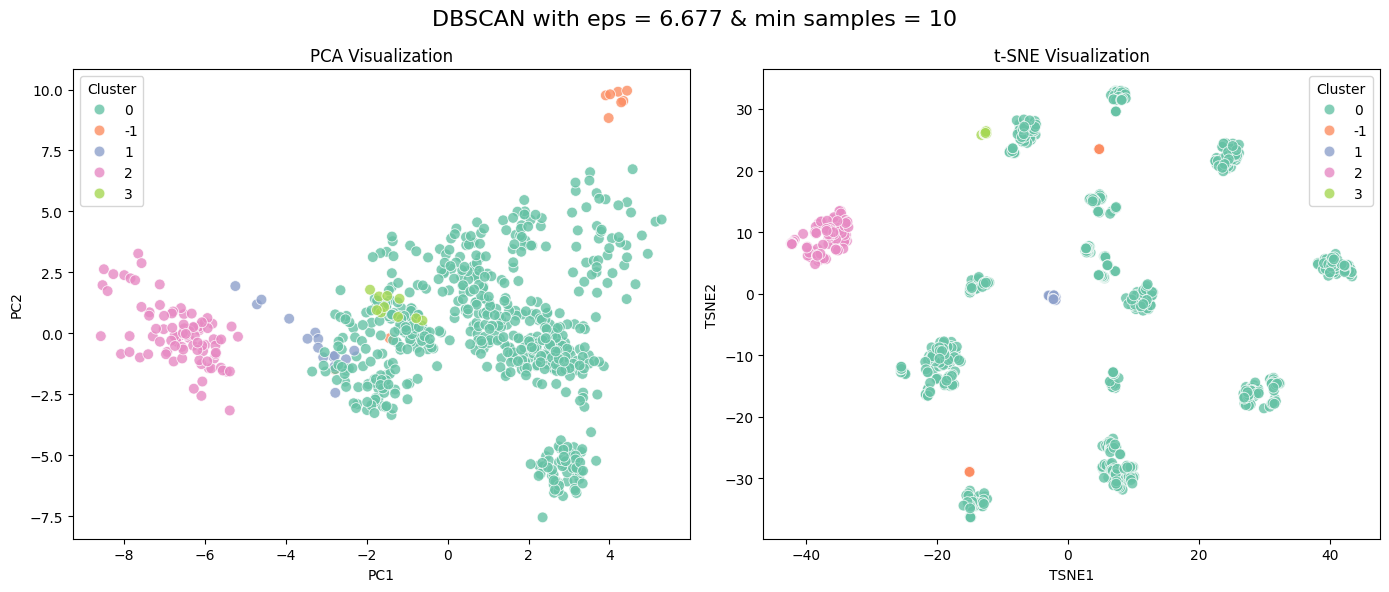

In [55]:
eps = 6.677
min_samples = 10

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_res = visualize_pca_tsne(X, dbscan, f'DBSCAN with eps = {eps} & min samples = {min_samples}')

# GMM

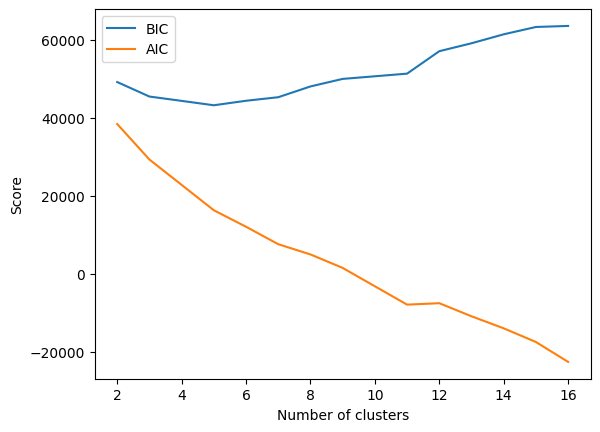

In [51]:
n_components = range(2, 17)
bic = []
aic = []

for k in n_components:
    gmm = GaussianMixture(n_components=k, random_state=seed) 
    gmm.fit(X)
    bic.append(gmm.bic(X))
    aic.append(gmm.aic(X))

plt.plot(n_components, bic, label='BIC')
plt.plot(n_components, aic, label='AIC')
plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.legend()
plt.show()

In [52]:
gmm = GaussianMixture(n_components=5, random_state=seed)

gmm.fit(X)


,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


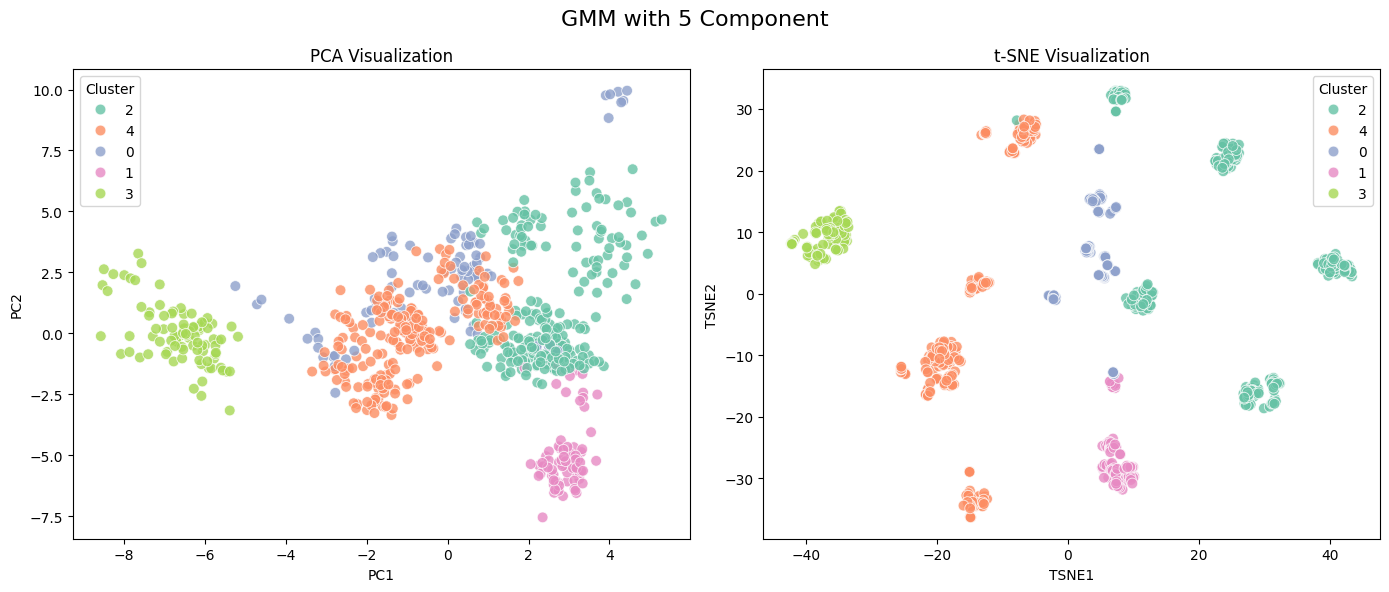

In [53]:
res_gmm = visualize_pca_tsne(X, gmm, 'GMM with 5 Component')